In [1]:
# Cell 1: Mount Drive and create I3D project folders

from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = "/content/drive/MyDrive/GM_Assignment2_TikHarm/I3D"

folders = [
    BASE_DIR,
    f"{BASE_DIR}/checkpoints",
    f"{BASE_DIR}/best_model",
    f"{BASE_DIR}/history",
    f"{BASE_DIR}/plots",
    f"{BASE_DIR}/logs",
    f"{BASE_DIR}/predictions"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("I3D project folders are ready.")
print("Base path:", BASE_DIR)
print("Created folders:")
for folder in folders:
    print("-", folder)

Mounted at /content/drive
I3D project folders are ready.
Base path: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D
Created folders:
- /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D
- /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/checkpoints
- /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/best_model
- /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/history
- /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/plots
- /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/logs
- /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/predictions


In [2]:
# Cell 2: Set Kaggle paths and dataset/extraction locations

import os

# Kaggle setup paths
os.makedirs("/root/.kaggle", exist_ok=True)

# Dataset info
KAGGLE_DATASET = "aryansraut/preprocessed-ucf-crime-dataset-visual"
ZIP_PATH = "/content/tikharm_i3d_dataset.zip"
EXTRACT_DIR = "/content"
DATASET_DIR = "/content/TikHarm_frames_16"

print("Kaggle folder ready:", os.path.exists("/root/.kaggle"))
print("Dataset slug:", KAGGLE_DATASET)
print("ZIP target:", ZIP_PATH)
print("Extraction directory:", EXTRACT_DIR)
print("Final dataset folder expected:", DATASET_DIR)
print("\nNext: we will upload kaggle.json and download the exact dataset.")

Kaggle folder ready: True
Dataset slug: aryansraut/preprocessed-ucf-crime-dataset-visual
ZIP target: /content/tikharm_i3d_dataset.zip
Extraction directory: /content
Final dataset folder expected: /content/TikHarm_frames_16

Next: we will upload kaggle.json and download the exact dataset.


In [4]:
# Cell 3: Upload Kaggle JSON and configure Kaggle API (fixed)

from google.colab import files
import shutil
import os

uploaded = files.upload()  # Upload your Kaggle JSON file here

json_files = [fname for fname in uploaded.keys() if fname.endswith(".json")]

if len(json_files) == 0:
    raise FileNotFoundError("No JSON file uploaded. Please upload your Kaggle API JSON file.")

uploaded_json = json_files[0]

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move(uploaded_json, "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API file uploaded and configured successfully.")
print("Original uploaded name:", uploaded_json)
print("Saved as: /root/.kaggle/kaggle.json")

Saving kaggle (2).json to kaggle (2) (1).json
Kaggle API file uploaded and configured successfully.
Original uploaded name: kaggle (2) (1).json
Saved as: /root/.kaggle/kaggle.json


In [5]:
# Cell 4: Verify Kaggle API and download the exact dataset ZIP

!kaggle --version
!kaggle datasets download -d aryansraut/preprocessed-ucf-crime-dataset-visual -p /content
!ls -lh /content | grep preprocessed-ucf-crime-dataset-visual

Kaggle CLI 2.0.0
Dataset URL: https://www.kaggle.com/datasets/aryansraut/preprocessed-ucf-crime-dataset-visual
License(s): apache-2.0
100% 1.04G/1.04G [01:08<00:00, 16.3MB/s]

-rw-r--r-- 1 root root 1.1G Feb 28 08:39 preprocessed-ucf-crime-dataset-visual.zip


In [6]:
# Cell 5: Extract dataset and verify the exact final folder

import os
import zipfile

ZIP_FILE = "/content/preprocessed-ucf-crime-dataset-visual.zip"
EXTRACT_DIR = "/content"
FINAL_DATASET_DIR = "/content/TikHarm_frames_16"

with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction completed.")
print("Final dataset folder exists:", os.path.exists(FINAL_DATASET_DIR))
print("Final dataset folder:", FINAL_DATASET_DIR)

Extraction completed.
Final dataset folder exists: True
Final dataset folder: /content/TikHarm_frames_16


In [7]:
# Cell 6: Verify dataset splits and class folders

import os

DATASET_DIR = "/content/TikHarm_frames_16"
expected_splits = ["train", "val", "test"]
expected_classes = {"Adult Content", "Harmful Content", "Safe", "Suicide"}

for split in expected_splits:
    split_path = os.path.join(DATASET_DIR, split)
    print(f"\nSplit: {split}")
    print("Exists:", os.path.exists(split_path))

    if os.path.exists(split_path):
        found_classes = sorted([
            d for d in os.listdir(split_path)
            if os.path.isdir(os.path.join(split_path, d))
        ])
        print("Found classes:", found_classes)
        print("All expected classes present:", set(found_classes) == expected_classes)


Split: train
Exists: True
Found classes: ['Adult Content', 'Harmful Content', 'Safe', 'Suicide']
All expected classes present: True

Split: val
Exists: True
Found classes: ['Adult Content', 'Harmful Content', 'Safe', 'Suicide']
All expected classes present: True

Split: test
Exists: True
Found classes: ['Adult Content', 'Harmful Content', 'Safe', 'Suicide']
All expected classes present: True


In [8]:
# Cell 7: Install required packages for I3D training

!pip install -q pytorchvideo av fvcore iopath

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 16.8 MB/s eta 0:00:00


In [9]:
# Cell 8: Import libraries and set basic project configuration

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision.transforms import functional as TF

DATASET_DIR = "/content/TikHarm_frames_16"
BASE_DIR = "/content/drive/MyDrive/GM_Assignment2_TikHarm/I3D"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

CLASS_NAMES = ["Adult Content", "Harmful Content", "Safe", "Suicide"]
CLASS_TO_IDX = {cls_name: idx for idx, cls_name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: cls_name for cls_name, idx in CLASS_TO_IDX.items()}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Train dir:", TRAIN_DIR)
print("Val dir:", VAL_DIR)
print("Test dir:", TEST_DIR)
print("Classes:", CLASS_TO_IDX)
print("Device:", device)

Train dir: /content/TikHarm_frames_16/train
Val dir: /content/TikHarm_frames_16/val
Test dir: /content/TikHarm_frames_16/test
Classes: {'Adult Content': 0, 'Harmful Content': 1, 'Safe': 2, 'Suicide': 3}
Device: cuda


In [10]:
# Cell 9: Create custom dataset class and build train/val/test datasets

class TikHarmFramesDataset(Dataset):
    def __init__(self, root_dir, class_to_idx, num_frames=16, image_size=(224, 224)):
        self.root_dir = root_dir
        self.class_to_idx = class_to_idx
        self.num_frames = num_frames
        self.image_size = image_size
        self.samples = []

        for class_name in sorted(os.listdir(root_dir)):
            class_path = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_path):
                continue

            label = class_to_idx[class_name]

            for clip_name in sorted(os.listdir(class_path)):
                clip_path = os.path.join(class_path, clip_name)
                if os.path.isdir(clip_path):
                    self.samples.append((clip_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        clip_path, label = self.samples[idx]

        frame_files = sorted([
            f for f in os.listdir(clip_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])[:self.num_frames]

        if len(frame_files) != self.num_frames:
            raise ValueError(f"Clip {clip_path} has {len(frame_files)} frames, expected {self.num_frames}")

        frames = []
        for frame_file in frame_files:
            frame_path = os.path.join(clip_path, frame_file)
            img = read_image(frame_path).float() / 255.0  # [C, H, W], range [0,1]
            img = TF.resize(img, self.image_size)
            frames.append(img)

        clip = torch.stack(frames, dim=1)  # [C, T, H, W]
        return clip, label

train_dataset = TikHarmFramesDataset(TRAIN_DIR, CLASS_TO_IDX)
val_dataset   = TikHarmFramesDataset(VAL_DIR, CLASS_TO_IDX)
test_dataset  = TikHarmFramesDataset(TEST_DIR, CLASS_TO_IDX)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 2762
Val samples: 396
Test samples: 790


In [11]:
# Cell 10: Create dataloaders and verify one batch shape

BATCH_SIZE = 4
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

clips, labels = next(iter(train_loader))

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("Clip batch shape:", clips.shape)   # expected: [B, C, T, H, W]
print("Label batch shape:", labels.shape) # expected: [B]
print("Sample labels:", labels.tolist())

Train batches: 691
Val batches: 99
Test batches: 198
Clip batch shape: torch.Size([4, 3, 16, 224, 224])
Label batch shape: torch.Size([4])
Sample labels: [1, 1, 2, 3]


In [12]:
# Cell 11: Load pretrained I3D model and replace final layer for 4 classes

import torch
import torch.nn as nn
from pytorchvideo.models.hub import i3d_r50

NUM_CLASSES = 4

model = i3d_r50(pretrained=True)

# Replace final projection layer for our 4 classes
in_features = model.blocks[-1].proj.in_features
model.blocks[-1].proj = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

print("I3D model loaded successfully.")
print("Final layer updated for", NUM_CLASSES, "classes.")
print("Device:", next(model.parameters()).device)

Downloading: "https://dl.fbaipublicfiles.com/pytorchvideo/model_zoo/kinetics/I3D_8x8_R50.pyth" to /root/.cache/torch/hub/checkpoints/I3D_8x8_R50.pyth


100%|██████████| 214M/214M [00:00<00:00, 241MB/s]


I3D model loaded successfully.
Final layer updated for 4 classes.
Device: cuda:0


In [13]:
# Cell 12: Define loss, optimizer, training settings, and save paths

LEARNING_RATE = 1e-4
NUM_EPOCHS = 10

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

BEST_MODEL_PATH = f"{BASE_DIR}/best_model/i3d_best.pth"
CHECKPOINT_PATH = f"{BASE_DIR}/checkpoints/i3d_checkpoint.pth"
HISTORY_PATH = f"{BASE_DIR}/history/i3d_history.json"
PLOT_PATH = f"{BASE_DIR}/plots/i3d_training_curves.png"

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
start_epoch = 0

print("Criterion:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", NUM_EPOCHS)
print("Best model path:", BEST_MODEL_PATH)
print("Checkpoint path:", CHECKPOINT_PATH)
print("History path:", HISTORY_PATH)

Criterion: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.0001
Epochs: 10
Best model path: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/best_model/i3d_best.pth
Checkpoint path: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/checkpoints/i3d_checkpoint.pth
History path: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/history/i3d_history.json


In [14]:
# Cell 13: Define train/validation functions and load checkpoint if it exists

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for clips, labels in loader:
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(clips)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for clips, labels in loader:
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(clips)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    history = checkpoint["history"]

    print("Checkpoint found. Resuming training.")
    print("Start epoch:", start_epoch)
    print("Best val acc so far:", best_val_acc)
else:
    print("No checkpoint found. Training will start from epoch 0.")

No checkpoint found. Training will start from epoch 0.


In [15]:
# Cell 14: Train I3D, validate each epoch, and save checkpoint/best model/history

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Accuracy: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Best model updated and saved.")

    # Save checkpoint every epoch
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "history": history
    }
    torch.save(checkpoint, CHECKPOINT_PATH)

    # Save history json every epoch
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f)

    print("Checkpoint and history saved.")

print("\nTraining completed.")
print("Best validation accuracy:", best_val_acc)


Epoch 1/10
Train Loss: 0.7717 | Train Accuracy: 0.7129
Val   Loss: 0.5794 | Val   Accuracy: 0.7854
Best model updated and saved.
Checkpoint and history saved.

Epoch 2/10
Train Loss: 0.4755 | Train Accuracy: 0.8327
Val   Loss: 0.6870 | Val   Accuracy: 0.8005
Best model updated and saved.
Checkpoint and history saved.

Epoch 3/10
Train Loss: 0.2965 | Train Accuracy: 0.9033
Val   Loss: 0.6668 | Val   Accuracy: 0.7955
Checkpoint and history saved.

Epoch 4/10
Train Loss: 0.1949 | Train Accuracy: 0.9352
Val   Loss: 0.9020 | Val   Accuracy: 0.7753
Checkpoint and history saved.

Epoch 5/10
Train Loss: 0.1341 | Train Accuracy: 0.9576
Val   Loss: 0.7100 | Val   Accuracy: 0.7980
Checkpoint and history saved.

Epoch 6/10
Train Loss: 0.1405 | Train Accuracy: 0.9522
Val   Loss: 0.7852 | Val   Accuracy: 0.8308
Best model updated and saved.
Checkpoint and history saved.

Epoch 7/10
Train Loss: 0.0707 | Train Accuracy: 0.9801
Val   Loss: 0.7376 | Val   Accuracy: 0.8005
Checkpoint and history saved.


In [16]:
# Cell 15: Load best saved I3D model and evaluate on test set

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model = model.to(device)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print("Best I3D model loaded from:", BEST_MODEL_PATH)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Best I3D model loaded from: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/best_model/i3d_best.pth
Test Loss: 0.9446
Test Accuracy: 0.7696


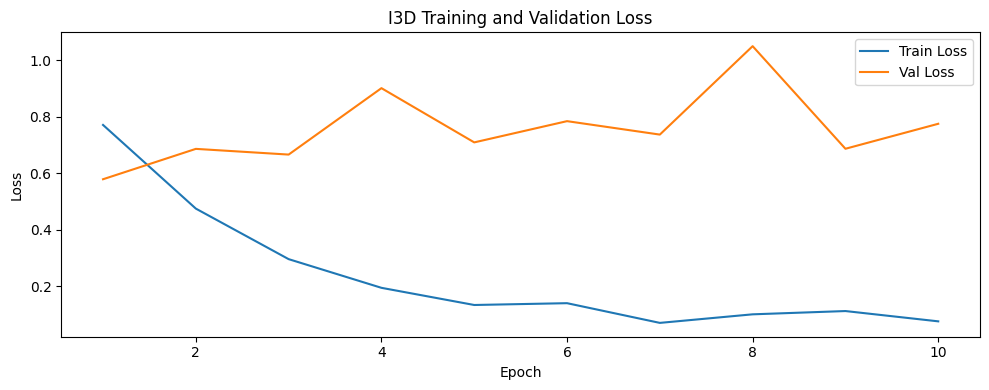

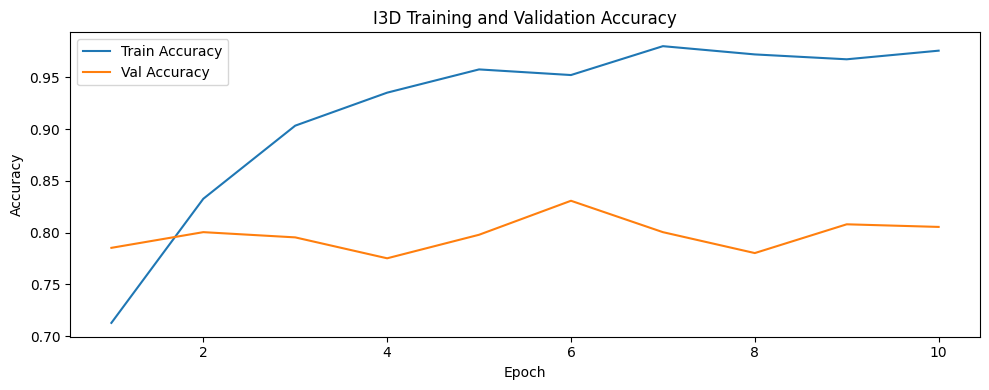

Loss plot saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/plots/i3d_training_curves.png
Accuracy plot saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/plots/i3d_accuracy_curves.png


In [17]:
# Cell 16: Plot and save training curves to Drive

import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("I3D Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH)
plt.show()

acc_plot_path = f"{BASE_DIR}/plots/i3d_accuracy_curves.png"

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("I3D Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(acc_plot_path)
plt.show()

print("Loss plot saved to:", PLOT_PATH)
print("Accuracy plot saved to:", acc_plot_path)

In [18]:
# Cell 17: Save final I3D results summary to Drive

final_results = {
    "model_name": "I3D",
    "num_epochs": NUM_EPOCHS,
    "best_val_accuracy": best_val_acc,
    "final_test_loss": test_loss,
    "final_test_accuracy": test_acc,
    "best_model_path": BEST_MODEL_PATH,
    "checkpoint_path": CHECKPOINT_PATH,
    "history_path": HISTORY_PATH,
    "loss_plot_path": PLOT_PATH,
    "accuracy_plot_path": f"{BASE_DIR}/plots/i3d_accuracy_curves.png"
}

RESULTS_JSON_PATH = f"{BASE_DIR}/history/i3d_final_results.json"
RESULTS_TXT_PATH = f"{BASE_DIR}/history/i3d_final_results.txt"

with open(RESULTS_JSON_PATH, "w") as f:
    json.dump(final_results, f, indent=4)

with open(RESULTS_TXT_PATH, "w") as f:
    f.write("I3D Final Results Summary\n")
    f.write("=========================\n")
    f.write(f"Model: I3D\n")
    f.write(f"Epochs: {NUM_EPOCHS}\n")
    f.write(f"Best Validation Accuracy: {best_val_acc:.4f}\n")
    f.write(f"Final Test Loss: {test_loss:.4f}\n")
    f.write(f"Final Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Best Model Path: {BEST_MODEL_PATH}\n")
    f.write(f"Checkpoint Path: {CHECKPOINT_PATH}\n")
    f.write(f"History Path: {HISTORY_PATH}\n")
    f.write(f"Loss Plot Path: {PLOT_PATH}\n")
    f.write(f"Accuracy Plot Path: {BASE_DIR}/plots/i3d_accuracy_curves.png\n")

print("Final results JSON saved to:", RESULTS_JSON_PATH)
print("Final results TXT saved to:", RESULTS_TXT_PATH)
print("\nSaved metrics:")
for k, v in final_results.items():
    print(f"{k}: {v}")

Final results JSON saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/history/i3d_final_results.json
Final results TXT saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/history/i3d_final_results.txt

Saved metrics:
model_name: I3D
num_epochs: 10
best_val_accuracy: 0.8308080808080808
final_test_loss: 0.9445951504957946
final_test_accuracy: 0.769620253164557
best_model_path: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/best_model/i3d_best.pth
checkpoint_path: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/checkpoints/i3d_checkpoint.pth
history_path: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/history/i3d_history.json
loss_plot_path: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/plots/i3d_training_curves.png
accuracy_plot_path: /content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/plots/i3d_accuracy_curves.png


In [19]:
# Cell 18: Verify all important saved I3D files

important_files = [
    BEST_MODEL_PATH,
    CHECKPOINT_PATH,
    HISTORY_PATH,
    PLOT_PATH,
    f"{BASE_DIR}/plots/i3d_accuracy_curves.png",
    f"{BASE_DIR}/history/i3d_final_results.json",
    f"{BASE_DIR}/history/i3d_final_results.txt"
]

print("I3D Saved Files Check:\n")
for file_path in important_files:
    print(f"{file_path} -->", os.path.exists(file_path))

I3D Saved Files Check:

/content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/best_model/i3d_best.pth --> True
/content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/checkpoints/i3d_checkpoint.pth --> True
/content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/history/i3d_history.json --> True
/content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/plots/i3d_training_curves.png --> True
/content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/plots/i3d_accuracy_curves.png --> True
/content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/history/i3d_final_results.json --> True
/content/drive/MyDrive/GM_Assignment2_TikHarm/I3D/history/i3d_final_results.txt --> True
